In [2]:
# Загрузка данных, предпросмотр датасета

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

df = pd.read_csv('C:/Users/anast/Downloads/telco_customer/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Общий обзор данных

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,"7,043.00","7,043.00","7,043.00"
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [4]:
# Просмотр целевой переменной, перевод значений в проценты

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64


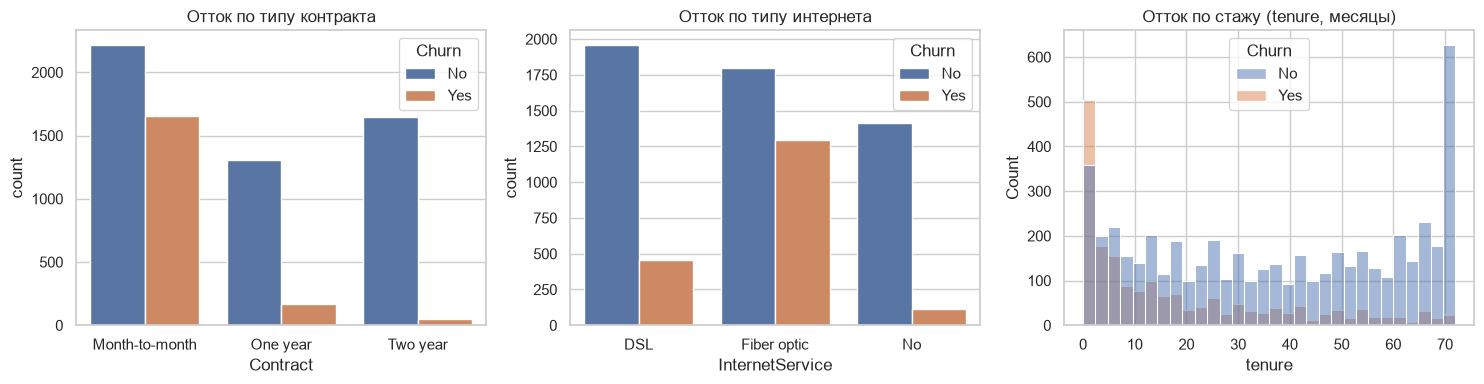

In [5]:
# Визуализация основных признаков

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Отток по типу контракта')

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1])
axes[1].set_title('Отток по типу интернета')

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[2])
axes[2].set_title('Отток по стажу (tenure, месяцы)')

plt.tight_layout()
plt.show()

Клиенты на месячном контракте уходят значительно чаще, чем клиенты на годовом / двухлетнем контракте (см. График 1).
Наблюдается спад оттока с ростом параметра tenure: чем дольше клиент сотрудничает с компанией, тем реже он уходит (см. График 3)

In [6]:
# Очистка и подготовка данных

print(df[df['TotalCharges'] == ' '].shape) # в 11 строках датасета переменная TotalCharges содержит пробел
# вместо числа / пустого значения

(11, 21)


In [7]:
# Конвертация в числовое значение / значение NaN; после конвертации остаются те же 11 строк с первоначальным значением NaN
# в переменной TotalCharges

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isna().sum())

11


In [8]:
# Поскольку строк такого типа в датасете немного (11 из 7043, 0.16%), а также поскольку они соответствуют клиентам
# без истории начислений, эти строки были удалены. После удаления в датасете осталось 7032 строк и 21 столбец

df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [9]:
# Удаление неинформативного для целей проекта столбца customerID

df = df.drop(columns=['customerID'])

In [10]:
# Превращение целевой переменной (первоначально текстовой) в числовой флаг

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [11]:
# Разделение признаков на числовые и категориальные, вывод категориальных признаков

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    col for col in df.columns
    if col not in numeric_features + ['Churn']
]
print(categorical_features)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
# One-Hot Encoding для категориальных признаков

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print(df_encoded.shape)

(7032, 31)


In [13]:
# Разделение на признаки (x) и целевую переменную (y)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [14]:
# Train / test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Task was destroyed but it is pending!
task: <Task pending name='Task-70' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\anast\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-71' coro=<Kernel.shell_main() running at C:\Users\anast\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\anast\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\anast\AppData\Local\Programs\Python\Python313\Lib\multiprocessing\reduction.py:104: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  class DupHandle(object):
Task was destroyed but it is pending!
task: <Task pending name='Task-71' coro=<Kernel.shell_main() running at C:\Users\anast\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Tas

Train: (5625, 30) Test: (1407, 30)


In [15]:
# Масштабирование числовых признаков

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [16]:
# Обучение логистической регрессии

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [17]:
# Оценка качевтва модели: предсказание на тестовой выборке

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

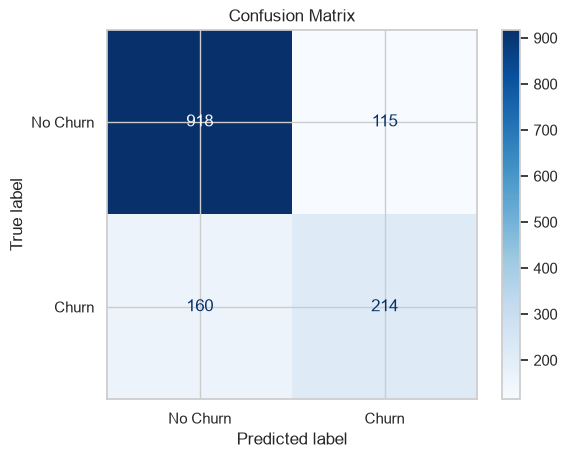

In [18]:
# Матрица ошибок

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [19]:
# Classification Report — precision, recall, F1

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



ROC-AUC: 0.836


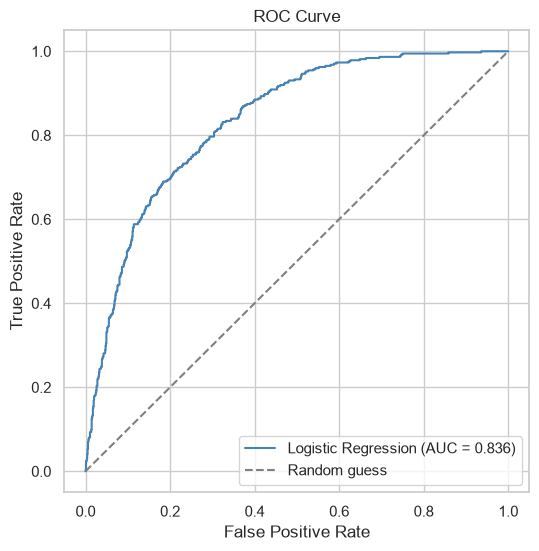

In [20]:
# ROC-AUC и ROC-кривая

from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {auc:.3f}')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [21]:
# Извлечение и сортировка коэффициентов

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coefficients.head(15))

                           feature  coefficient
0                           tenure        -1.36
25               Contract_Two year        -1.35
10     InternetService_Fiber optic         1.12
24               Contract_One year        -0.74
2                     TotalCharges         0.64
7                 PhoneService_Yes        -0.52
1                   MonthlyCharges        -0.45
28  PaymentMethod_Electronic check         0.39
21                 StreamingTV_Yes         0.37
13              OnlineSecurity_Yes        -0.37
9                MultipleLines_Yes         0.36
23             StreamingMovies_Yes         0.35
19                 TechSupport_Yes        -0.33
26            PaperlessBilling_Yes         0.29
6                   Dependents_Yes        -0.23


In [22]:
# Перевод коэффициентов в Odds Ratio

coefficients['odds_ratio'] = np.exp(coefficients['coefficient'])
print(coefficients.head(15))

                           feature  coefficient  odds_ratio
0                           tenure        -1.36        0.26
25               Contract_Two year        -1.35        0.26
10     InternetService_Fiber optic         1.12        3.07
24               Contract_One year        -0.74        0.48
2                     TotalCharges         0.64        1.90
7                 PhoneService_Yes        -0.52        0.59
1                   MonthlyCharges        -0.45        0.64
28  PaymentMethod_Electronic check         0.39        1.47
21                 StreamingTV_Yes         0.37        1.45
13              OnlineSecurity_Yes        -0.37        0.69
9                MultipleLines_Yes         0.36        1.44
23             StreamingMovies_Yes         0.35        1.42
19                 TechSupport_Yes        -0.33        0.72
26            PaperlessBilling_Yes         0.29        1.34
6                   Dependents_Yes        -0.23        0.79


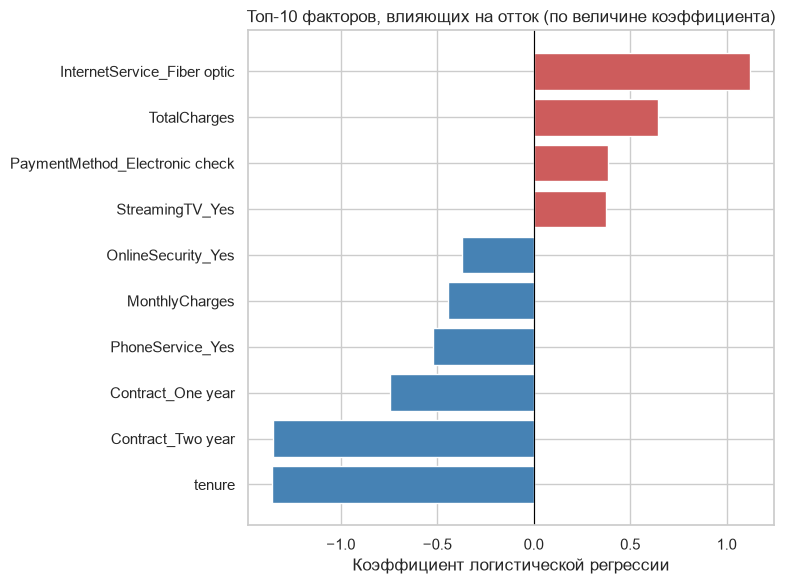

In [23]:
# Визуализация факторов с наибольшим влиянием

top_features = coefficients.head(10).sort_values('coefficient')

plt.figure(figsize=(8, 6))
colors = ['indianred' if c > 0 else 'steelblue' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Топ-10 факторов, влияющих на отток (по величине коэффициента)')
plt.xlabel('Коэффициент логистической регрессии')
plt.tight_layout()
plt.show()

Основные выводы

- Логистическая регрессия достигает ROC-AUC ≈ 0.836 на тестовой выборке — модель хорошо ранжирует клиентов по риску оттока
- Recall для класса Churn составляет 57% при precision 65% — модель находит чуть больше половины реальных случаев оттока; это заметно ниже общей accuracy (80%), что ожидаемо при дисбалансе классов (базовый уровень оттока 26.5%) и подчёркивает, почему для этой задачи recall важнее голой accuracy
- Сильнее всего повышают риск оттока: оптоволоконный интернет (odds ratio ≈ 3.07 — почти втрое выше шансы оттока), высокий TotalCharges,
  оплата через Electronic check, наличие Streaming TV
- Сильнее всего снижают риск оттока: длительный стаж (tenure), длинный
  контракт (Two year снижает шансы почти в 4 раза, One year — примерно
  вдвое относительно месячного), наличие услуги Online Security
- Практический вывод для бизнеса: в зоне наибольшего риска — клиенты на
  месячном контракте, с оптоволоконным интернетом, оплатой через
  Electronic check и без подключённой Online Security — именно этот
  профиль стоит в первую очередь охватывать программами удержания
  (например, предложением перейти на длительный контракт или подключить
  Online Security)